# 02 — Is industry momentum alpha, or factor exposure?

**Strategy (Moskowitz & Grinblatt 1999 style).** At the end of each month $t$, rank the 49 Fama–French industries on their cumulative return from $t-11$ to $t-1$ (12-month lookback, skipping the most recent month). Go long the top 10 and short the bottom 10, equal-weighted; hold for month $t+1$.

**Look-ahead check.** The weights for month $t+1$ use returns only through $t-1$; `strategy_returns` multiplies *lagged* weights by current returns, and `tests/test_core.py` verifies that rewriting future data never changes past signals, weights or P&L.

In [1]:
import numpy as np, pandas as pd
from IPython.display import Image, display
from factor_neutrality import data, factors, regression as rg, strategy as st, performance as pf
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.width", 160)
ROOT = __import__("pathlib").Path.cwd().parent
TAB, FIG = ROOT / "results" / "tables", ROOT / "results" / "figures"


In [2]:
ind = data.industries_49()
ff3, ff5, umd = data.ff3(), data.ff5(), data.umd()
f = ff3.drop(columns="RF").join(ff5[["SMB","RMW","CMA"]].rename(columns={"SMB":"SMB5"}), how="inner").join(umd)
s = st.build(ind, lookback=12, skip=1, n=10, cost_bps=25).loc["1963-07":f.index[-1]]
pd.DataFrame({"gross": pf.summary(s["gross"]), "net of 25bp": pf.summary(s["net"]),
              "market": pf.summary(f.loc[s.index, "Mkt-RF"])})

,gross,net of 25bp,market
Months,758.000,758.000,758.000
Ann. mean (%),8.629,6.007,7.221
Ann. vol (%),15.380,15.404,15.445
Sharpe,0.561,0.390,0.468
t(mean),4.459,3.099,3.716
Skew,-0.759,-0.744,-0.491
Ex. kurt,5.548,5.488,1.716
Max DD (%),-52.998,-57.421,-55.714
Hit rate (%),59.235,57.124,59.894


## The neutralisation ladder

We regress the strategy on progressively richer factor sets. If alpha survives every benchmark, the strategy has something the known factors don't capture. If it vanishes once a factor is added, the 'alpha' was compensation for that factor's risk.

In [3]:
rows = {}
for m in ["CAPM", "FF3", "FF3+UMD", "FF5", "FF5+UMD"]:
    ft = rg.fit(s["gross"], f[rg.MODELS[m]])
    rows[m] = {"alpha %/yr": 1200*ft.alpha, "t (NW)": ft.alpha_t, "UMD beta": ft.params.get("UMD", np.nan),
               "HML beta": ft.params.get("HML", np.nan), "adj R2": ft.r2_adj}
pd.DataFrame(rows).T

,alpha %/yr,t (NW),UMD beta,HML beta,adj R2
CAPM,9.396,4.905,NaN,NaN,0.010
FF3,10.784,5.752,NaN,-0.300,0.047
FF3+UMD,2.315,2.088,0.864,-0.010,0.665
FF5,10.419,4.921,NaN,-0.394,0.052
FF5+UMD,2.763,2.464,0.867,0.011,0.668


**Reading.** CAPM sees a ~9%/yr alpha (t≈4.9). FF3 makes it look *better* — the strategy is short value, and HML had a positive premium. But once UMD (stock-level momentum) is added, R² jumps from ≈0.05 to ≈0.67 and alpha shrinks by roughly three quarters, to a t-statistic near 2: below the Harvey–Liu–Zhu (2016) t > 3 hurdle and zero after realistic costs.

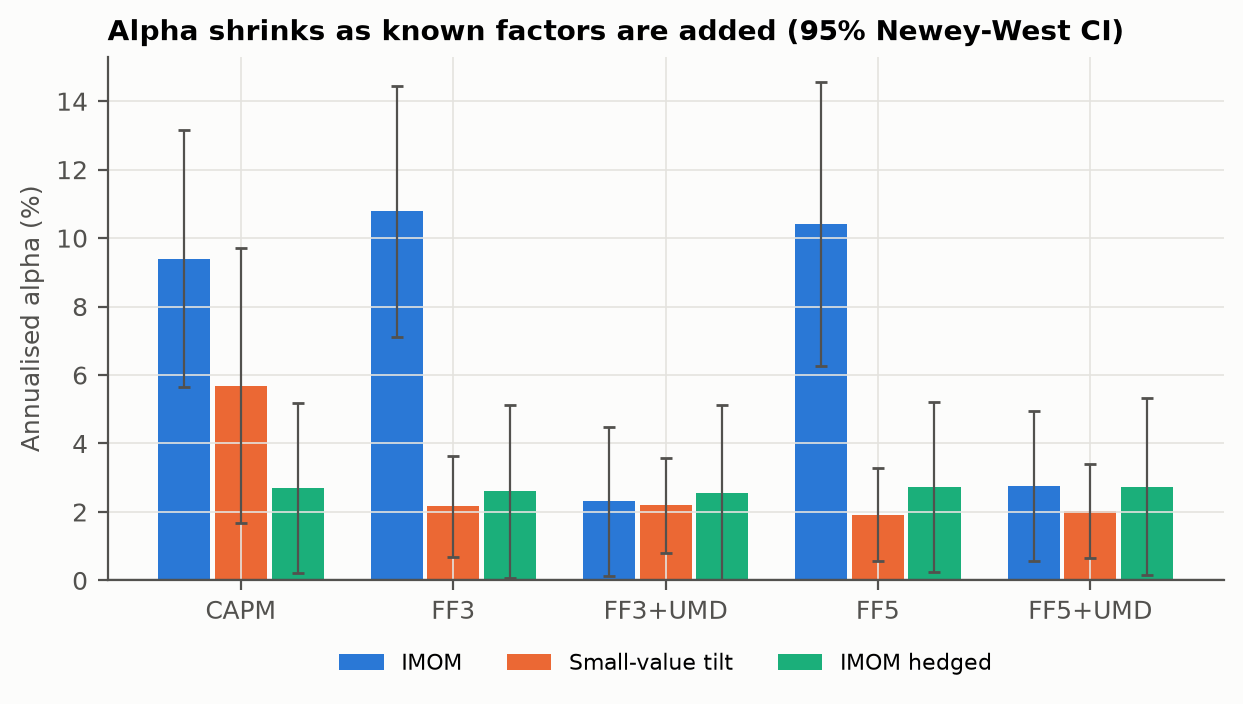

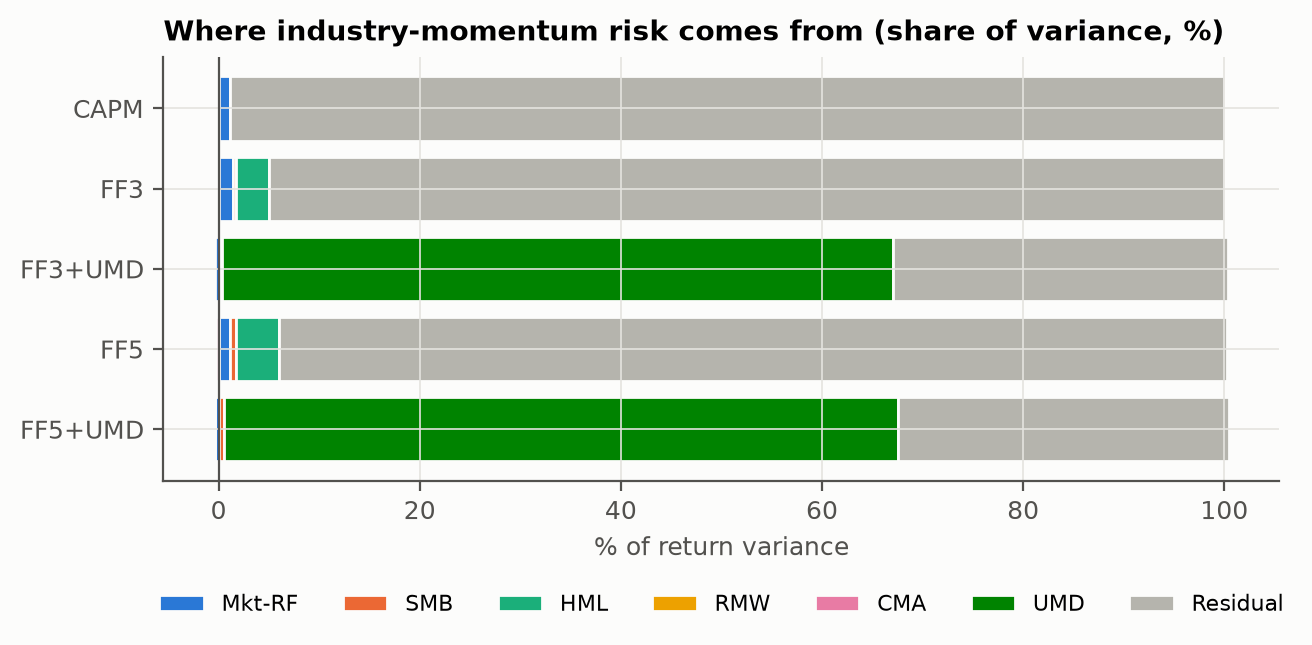

In [4]:
display(Image(FIG / 'F11_alpha_by_model.png')); display(Image(FIG / 'F17_risk_decomposition.png'))

## Ex-ante factor neutralisation

To build a *tradable* factor-neutral version we estimate betas on the previous 60 months only, and short $\hat\beta_{t-1}'f_t$ each month. Using full-sample betas instead would be look-ahead bias: it would make the hedge look perfect in hindsight.

In [5]:
h = st.hedge_ex_ante(s["gross"], f[["Mkt-RF","SMB","HML","UMD"]], 60)
ft = rg.fit(h["hedged"], f[rg.MODELS["FF5+UMD"]])
print(pf.summary(h["hedged"]).round(2).to_dict())
print(f"FF5+UMD alpha of hedged series: {1200*ft.alpha:.2f}%/yr, t = {ft.alpha_t:.2f}; residual UMD beta = {ft.params['UMD']:.3f}")

{'Months': 698.0, 'Ann. mean (%)': 2.64, 'Ann. vol (%)': 9.4, 'Sharpe': 0.28, 't(mean)': 2.14, 'Skew': 0.38, 'Ex. kurt': 1.5, 'Max DD (%)': -36.24, 'Hit rate (%)': 53.15}
FF5+UMD alpha of hedged series: 2.74%/yr, t = 2.08; residual UMD beta = 0.000


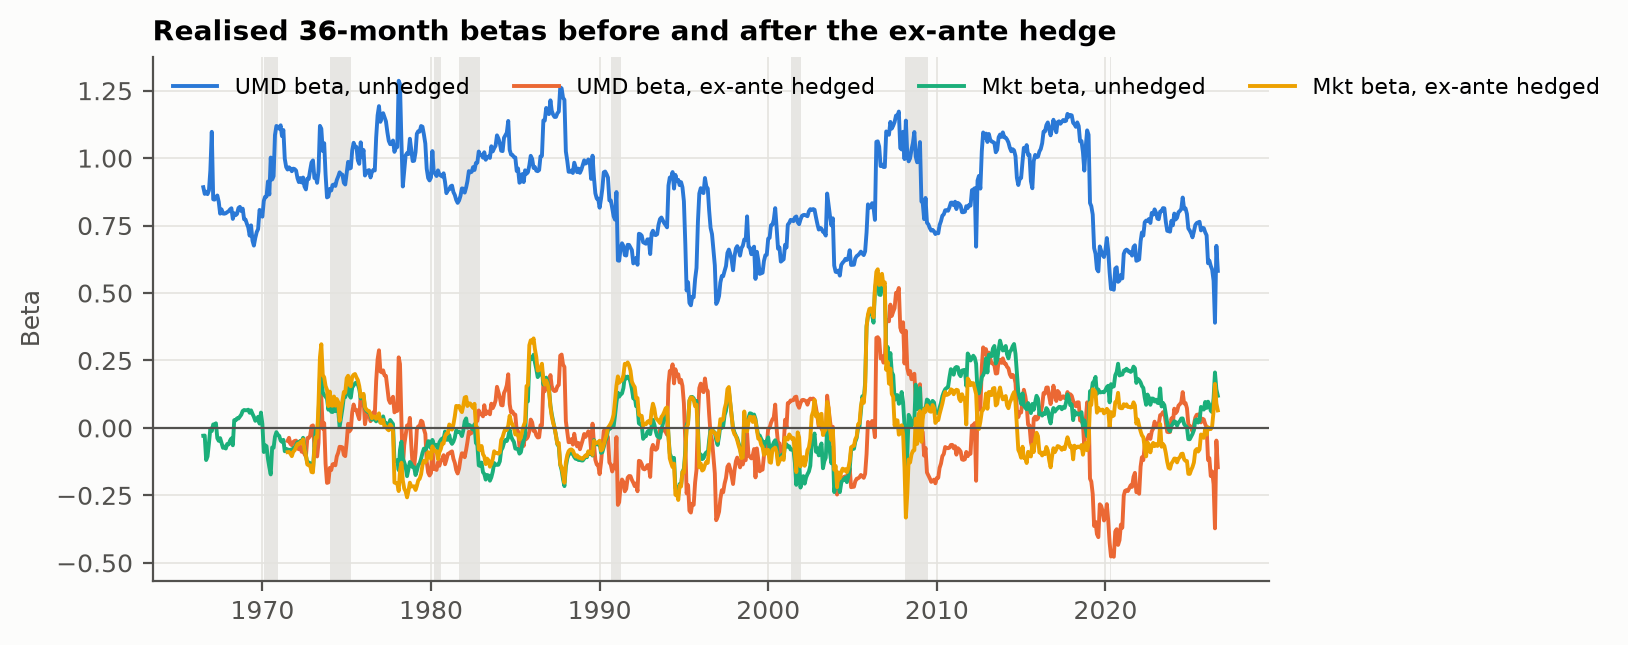

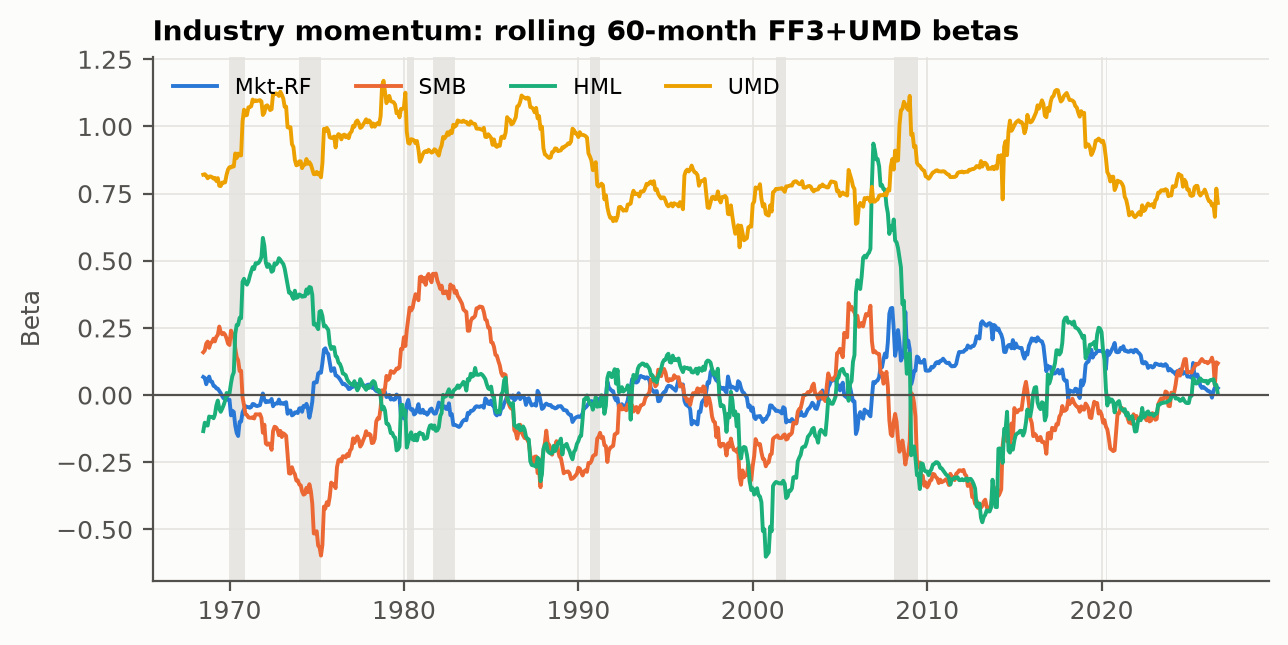

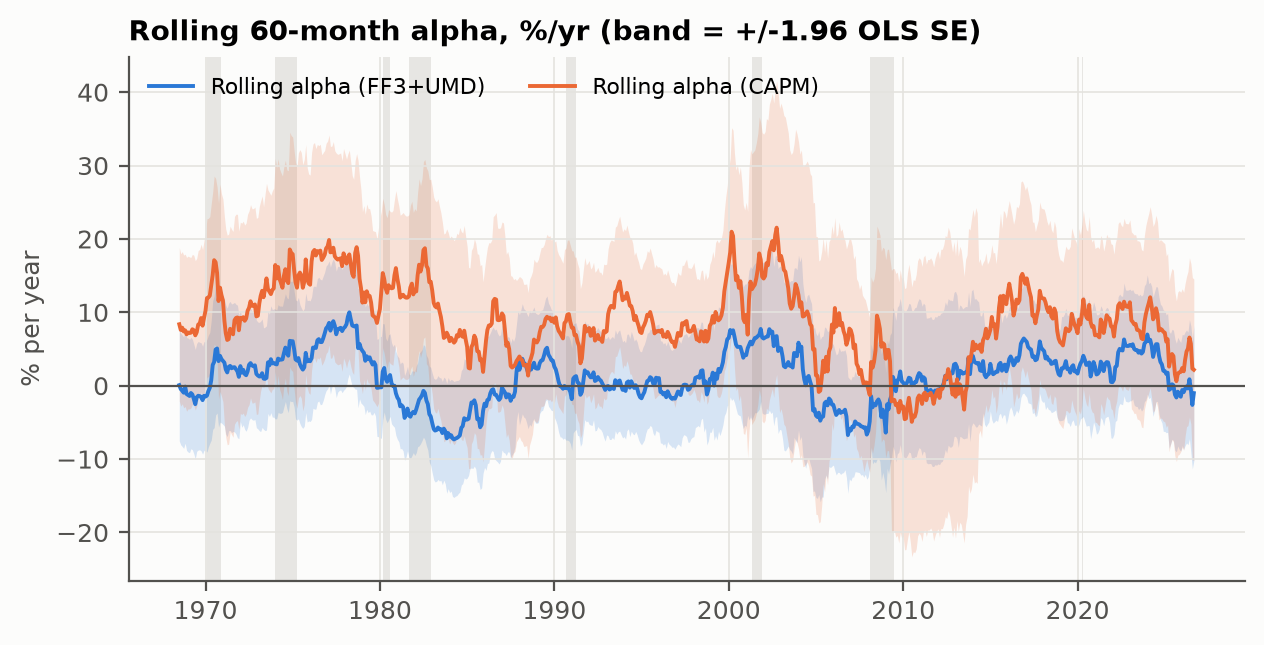

In [6]:
display(Image(FIG / 'F19_hedge_effectiveness.png')); display(Image(FIG / 'F13_rolling_betas.png')); display(Image(FIG / 'F14_rolling_alpha.png'))

## The control case: a small-value tilt

Holding the smallest-size, highest-BE/ME portfolio has a big CAPM alpha. FF3 explains most of it by loadings of ≈1.1 on SMB and ≈0.5 on HML — the textbook case of 'alpha' that is really factor risk. Notably, a residual FF3 alpha re-appears after 1991 (see notebook 03).

In [7]:
pd.read_csv(TAB / 'T09_regressions_smallvalue.csv', index_col=0)

,alpha (%/yr),t(alpha),Mkt-RF,t(Mkt-RF),SMB,t(SMB),HML,t(HML),RMW,t(RMW),CMA,t(CMA),UMD,t(UMD),adj R2,N
CAPM,5.692,2.771,1.064,23.920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.575,758.000
FF3,2.162,2.895,0.945,52.650,1.099,22.780,0.692,23.515,NaN,NaN,NaN,NaN,NaN,NaN,0.908,758.000
FF3+UMD,2.199,3.103,0.945,54.919,1.099,22.701,0.691,21.631,NaN,NaN,NaN,NaN,-0.004,-0.146,0.907,758.000
FF5,1.915,2.768,0.962,43.814,1.078,27.156,0.411,6.991,-0.016,-0.349,0.239,1.892,NaN,NaN,0.905,758.000
FF5+UMD,2.031,2.874,0.960,42.448,1.078,27.494,0.405,7.282,-0.014,-0.328,0.243,1.986,-0.013,-0.502,0.905,758.000
